<a href="https://colab.research.google.com/github/embob1/ML-fundamentals-2026/blob/main/assignment_1_MOHAMED_EMBABY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip

--2026-03-04 07:57:22--  https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘bank-additional.zip’

bank-additional.zip     [  <=>               ] 434.15K  1.46MB/s    in 0.3s    

2026-03-04 07:57:23 (1.46 MB/s) - ‘bank-additional.zip’ saved [444572]



In [3]:
import zipfile

with zipfile.ZipFile("bank-additional.zip", "r") as zip_ref:
    zip_ref.extractall()

print("Unzipped!")

Unzipped!


In [4]:
df = pd.read_csv("bank-additional/bank-additional.csv", sep=";")
print("Shape:", df.shape)
df.head()

Shape: (4119, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


The dataset contains 4,119 observations and 21 variables.

The dataset includes both categorical and numerical features.

Categorical variables describe demographic and campaign-related information (e.g., job, marital status, education, contact type).

Numerical variables include age, campaign information, and macroeconomic indicators.

The target variable y indicates whether the client subscribed to a term deposit.

In [5]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [6]:
df['y'].value_counts()

,count
y,
no,3668
yes,451


In [7]:
df['y'].value_counts(normalize=True)

,proportion
y,
no,0.890507
yes,0.109493


The target variable y is imbalanced.


---


Approximately 89% of clients did not subscribe to a term deposit, while only 11% subscribed.

This indicates a significant class imbalance, which may affect model training and evaluation.

In particular, accuracy alone would not be an appropriate metric, since a model predicting only “no” would already achieve around 89% accuracy.





## Exploratory Visualizations

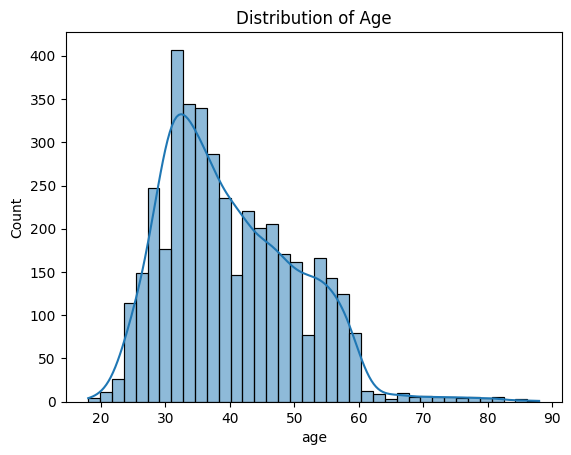

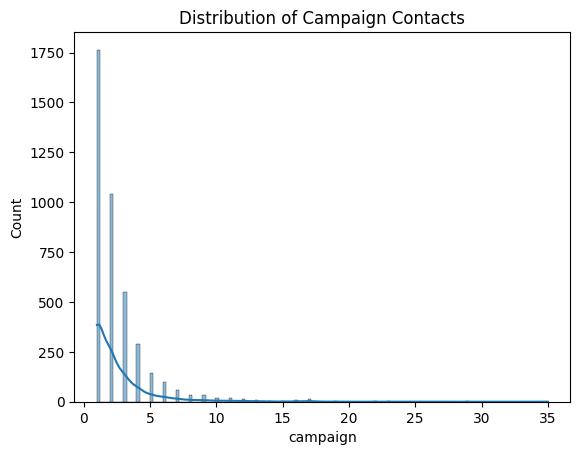

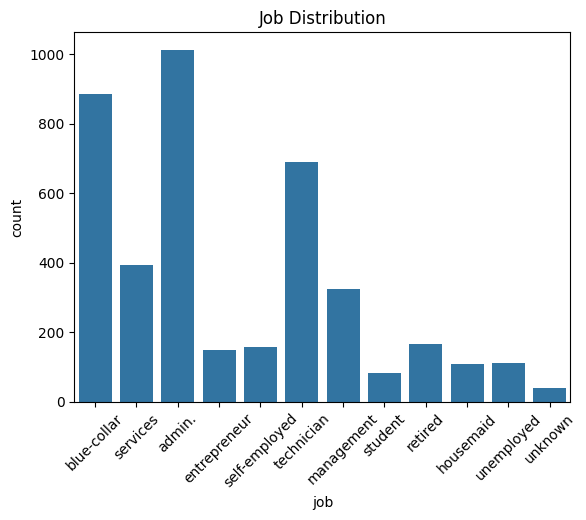

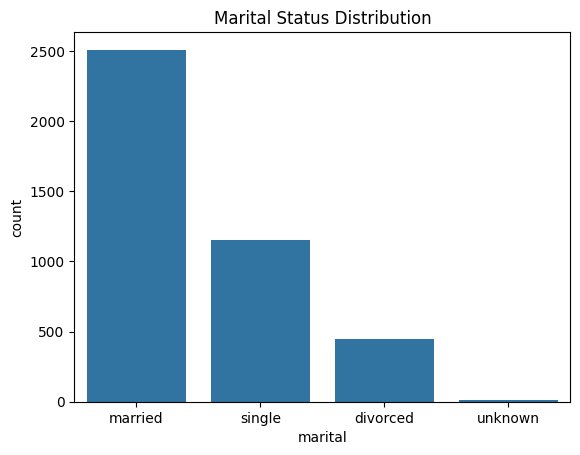

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Numerical variable 1
sns.histplot(df['age'], kde=True)
plt.title("Distribution of Age")
plt.show()

# Numerical variable 2
sns.histplot(df['campaign'], kde=True)
plt.title("Distribution of Campaign Contacts")
plt.show()

# Categorical variable 1
sns.countplot(x='job', data=df)
plt.xticks(rotation=45)
plt.title("Job Distribution")
plt.show()

# Categorical variable 2
sns.countplot(x='marital', data=df)
plt.title("Marital Status Distribution")
plt.show()

In [9]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop("y", axis=1)
y = df["y"]

# First split: Train (60%) and Temp (40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    stratify=y,
    random_state=42
)

# Second split: Validation (20%) and Test (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (2471, 20)
Validation shape: (824, 20)
Test shape: (824, 20)


Data Splitting Strategy


---


The dataset was split into:

60% training set

20% validation set

20% test set

The splitting was used to preserve the original class distribution of the target variable.

Since the dataset is imbalanced (approximately 89% “no” and 11% “yes”), stratification ensures that all subsets maintain similar proportions.

Without stratification, the class distribution could differ across splits, leading to unreliable model evaluation.

In [10]:
X_train.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [11]:
(X_train == "unknown").sum()

,0
age,0
job,20
marital,7
education,104
default,492
housing,55
loan,55
contact,0
month,0
day_of_week,0


Missing Values Analysis


---



The dataset does not contain explicit missing values (no NaN values were detected).

However, several categorical variables contain the category "unknown", which represents implicit missing values.

The variables affected include: job, marital, education, default, housing, loan


In this assignment, "unknown" will be treated as a valid category rather than being removed or imputed.

Removing these rows would unnecessarily reduce the dataset size, and imputing them could introduce bias.

When categorical encoding is applied later, "unknown" will naturally be handled as an additional category.

In [12]:
X_train = X_train.drop("duration", axis=1)
X_val = X_val.drop("duration", axis=1)
X_test = X_test.drop("duration", axis=1)

In [13]:
categorical_cols = X_train.select_dtypes(include="object").columns
numerical_cols = X_train.select_dtypes(exclude="object").columns

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')

Numerical columns:
Index(['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')


Identification of Categorical and Numerical Variables


---



After removing the leakage variable duration, the remaining features were separated into categorical and numerical variables.

Categorical variables include:
Job, marital, education, default, housing, loan, contact, month, day_of_week,poutcome

These variables represent qualitative information and will require categorical encoding before being used in a Logistic Regression model.

Numerical variables include:
age, campaign, pdays, previous, emp.var.rate, cons.price.idx, cons.conf.idx ,euribor3m, nr.employed

These variables are already numeric but will later require feature scaling to ensure proper optimization of the Logistic Regression model.

In [14]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit ONLY on training data
encoder.fit(X_train[categorical_cols])

# Transform datasets
X_train_encoded = encoder.transform(X_train[categorical_cols])
X_val_encoded = encoder.transform(X_val[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

In [15]:
encoded_feature_names = encoder.get_feature_names_out(categorical_cols)

print(len(encoded_feature_names))

53


In [16]:
X_train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=encoded_feature_names,
    index=X_train.index
)

X_val_encoded_df = pd.DataFrame(
    X_val_encoded,
    columns=encoded_feature_names,
    index=X_val.index
)

X_test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=encoded_feature_names,
    index=X_test.index
)

In [17]:
X_train_final = pd.concat(
    [X_train[numerical_cols], X_train_encoded_df],
    axis=1
)

X_val_final = pd.concat(
    [X_val[numerical_cols], X_val_encoded_df],
    axis=1
)

X_test_final = pd.concat(
    [X_test[numerical_cols], X_test_encoded_df],
    axis=1
)

print("Final train shape:", X_train_final.shape)

Final train shape: (2471, 62)


Encoding of Categorical Variables


---


Categorical variables were encoded using One-Hot Encoding.

The encoder was fitted only on the training set to avoid data leakage.

The same fitted encoder was then used to transform the validation and test sets.

After encoding, the transformed categorical features were combined with the numerical features to create the final feature matrices for modeling.




In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler()

# Fit only on numerical columns of training data
scaler.fit(X_train[numerical_cols])

StandardScaler()

In [20]:
X_train_scaled_num = scaler.transform(X_train[numerical_cols])
X_val_scaled_num = scaler.transform(X_val[numerical_cols])
X_test_scaled_num = scaler.transform(X_test[numerical_cols])

In [21]:
X_train_scaled_num_df = pd.DataFrame(
    X_train_scaled_num,
    columns=numerical_cols,
    index=X_train.index
)

X_val_scaled_num_df = pd.DataFrame(
    X_val_scaled_num,
    columns=numerical_cols,
    index=X_val.index
)

X_test_scaled_num_df = pd.DataFrame(
    X_test_scaled_num,
    columns=numerical_cols,
    index=X_test.index
)

In [22]:
X_train_final = pd.concat(
    [X_train_scaled_num_df, X_train_encoded_df],
    axis=1
)

X_val_final = pd.concat(
    [X_val_scaled_num_df, X_val_encoded_df],
    axis=1
)

X_test_final = pd.concat(
    [X_test_scaled_num_df, X_test_encoded_df],
    axis=1
)

print("Final scaled train shape:", X_train_final.shape)

Final scaled train shape: (2471, 62)


Feature Scaling


---


Numerical features were standardized using StandardScaler.

The scaler was fitted only on the training set to avoid data leakage.

The same fitted scaler was then applied to the validation and test sets.

Scaling ensures that all numerical features have mean 0 and variance 1, which improves optimization stability and ensures that regularization treats features fairly.

In [23]:
y_train.value_counts(normalize=True)

,proportion
y,
no,0.890328
yes,0.109672


## Feature Selection Analysis

In [24]:
# Low variance check
low_variance = X_train_final.var().sort_values().head()
print("Lowest variance features:")
print(low_variance)

Lowest variance features:
default_yes             0.000405
education_illiterate    0.000405
marital_unknown         0.002826
month_dec               0.006436
job_unknown             0.008032
dtype: float64


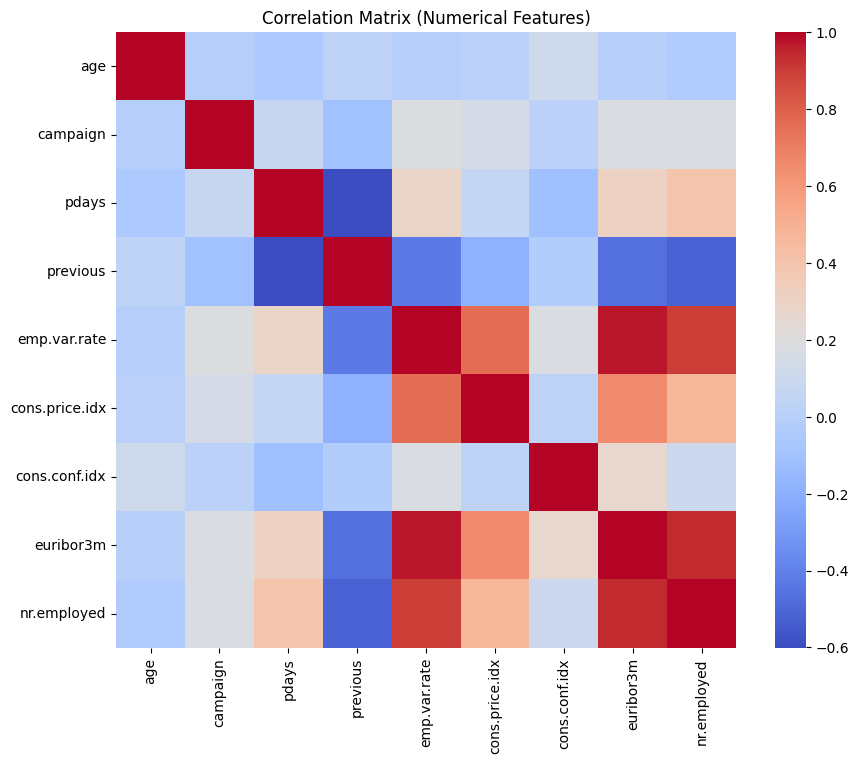

In [25]:
corr_matrix = X_train_scaled_num_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title("Correlation Matrix (Numerical Features)")
plt.show()

No features with extremely low variance were identified.

The correlation matrix shows some correlation among the variables. However, no features were removed because:

- Logistic Regression with regularization can handle correlated predictors.
- Removing correlated features could reduce interpretability.
- Feature selection must be performed on training data only to avoid leakage.

If feature selection were performed before splitting, information from validation/test sets could influence training, resulting in optimistic evaluation.

## Class Imbalance Handling

The training set is imbalanced (~89% no, ~11% yes).

Instead of applying SMOTE or oversampling, Logistic Regression was trained using `class_weight="balanced"`.

This approach adjusts the loss function to penalize misclassification of the minority class more heavily.

Applying resampling before splitting would cause data leakage, as synthetic samples would contaminate validation and test sets.

Therefore, class balancing was applied only during training.

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_final, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [27]:
y_val_pred = model.predict(X_val_final)

print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred, pos_label="yes"))
print("Recall:", recall_score(y_val, y_val_pred, pos_label="yes"))

Accuracy: 0.8361650485436893
Precision: 0.35294117647058826
Recall: 0.6


Logistic Regression Validation Results


---


The Logistic Regression model was trained using class balancing to address class imbalance.

On the validation set:

Accuracy = 83.6%

Precision = 35.3%

Recall = 60.0%

Although the overall accuracy is lower than the Zero Rule baseline (~89%), this is expected because the model is attempting to correctly identify the minority class (“yes”).

The recall of 60% indicates that the model successfully detects a substantial portion of actual subscribers.

This demonstrates that the model is learning meaningful patterns rather than simply predicting the majority class.

In [28]:
# Zero rule baseline (always predict "no")
y_val_zero = ["no"] * len(y_val)

print("Zero Rule Accuracy:", accuracy_score(y_val, y_val_zero))
print("Zero Rule Recall (yes):", recall_score(y_val, y_val_zero, pos_label="yes"))

Zero Rule Accuracy: 0.8907766990291263
Zero Rule Recall (yes): 0.0


Comparison with Zero Rule Baseline


---


The Zero Rule baseline predicts the majority class (“no”) for all observations.

Zero Rule Accuracy: 89.1%

Zero Rule Recall (yes): 0%

Although the Zero Rule achieves higher accuracy, it completely fails to detect subscribers.

In contrast, the Logistic Regression model achieves:

Accuracy: 83.6%

Recall (yes): 60%

While overall accuracy is lower, the model substantially improves detection of the minority class.

This demonstrates why accuracy alone is not an appropriate metric in imbalanced classification problems.

## Task Ordering and Pipeline Discipline


---


The data preparation steps were executed in a structured order to prevent data leakage and ensure reliable evaluation.

### 1. Identify the Prediction Target

The target variable `y` was identified before any preprocessing.  
Only the definition of the prediction objective was used at this stage.  
Using outcome-related variables as features would cause leakage.

### 2. Initial Data Exploration

Exploratory analysis was performed to understand structure, feature types, and class distribution.  
No transformations were fitted and no parameters were learned at this stage.  
This ensured that validation and test data were not influencing preprocessing decisions.

### 3. Train/Validation/Test Split

The dataset was split into 60% training, 20% validation, and 20% test sets using stratification.  
This step was performed before any transformation.

Allowed information: full dataset structure and target distribution.  
Not allowed: learning transformation parameters from the full dataset.

If scaling or encoding were performed before splitting, statistics from validation and test sets would leak into training.

### 4. Leakage Removal

The variable `duration` was removed because it is not available at prediction time.  
Including it would cause target leakage and artificially inflate model performance.

### 5. Missing Value Handling

Implicit missing values ("unknown") were identified and treated as valid categories.  
No imputation statistics were learned, so no leakage occurred.

### 6. Encoding Categorical Variables

One-Hot Encoding was fitted exclusively on the training set and then applied to validation and test sets.

If fitted on the full dataset, category information from validation/test sets would influence training.

### 7. Feature Scaling

StandardScaler was fitted only on training numerical features.

If scaling were applied before splitting, the mean and variance of validation/test data would influence model training.

### 8. Class Imbalance Handling

Class imbalance was addressed using `class_weight="balanced"` during model training.

Resampling before splitting would introduce synthetic information into validation/test sets and invalidate evaluation.

### 9. Logistic Regression

The final model was trained only after all preprocessing steps were completed.  
Its purpose was to verify pipeline coherence, not to maximize predictive performance.

## AI Assistance Disclosure

## AI Assistance Disclosure

Artificial intelligence tools (ChatGPT) were used to assist with:
- Clarifying conceptual explanations,
- Improving the structure and wording of written sections,
- Debugging minor code issues.

All modeling decisions, preprocessing steps, and implementation choices were reviewed, understood, and validated independently by me.

The final notebook reflects my own understanding of the machine learning pipeline and course material.

Reference:
OpenAI. (2025). ChatGPT (Large language model). https://chat.openai.com